In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error


In [19]:
# Load data (replace the path with your dataset path)
data = pd.read_csv('exported_metrics.csv')

# Convert timestamp to datetime (if necessary)
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Ensure the data is sorted by timestamp
data.sort_values('timestamp', inplace=True)

# Select relevant columns
data = data[['timestamp', 'disk_usage_percent', 'disk_read_bytes', 'disk_write_bytes']]

# Handle missing values (optional: you can drop or fill)
data.fillna(method='ffill', inplace=True)  # Forward fill missing values

# Normalize the features using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[['disk_usage_percent', 'disk_read_bytes', 'disk_write_bytes']])

# Prepare the dataset: Use disk_usage_percent for forecasting
disk_usage = data_scaled[:, 0]  # This is the target we want to forecast

# Split into training and test sets
train_size = int(len(disk_usage) * 0.8)
train, test = disk_usage[:train_size], disk_usage[train_size:]

<ipython-input-19-481ba5db09af>:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)  # Forward fill missing values


In [20]:
# Apply Exponential Smoothing
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
model_fit = model.fit()

# Forecast the future values (on the test set)
forecast = model_fit.forecast(len(test))

# Inverse the scaling to get back to the original values for both forecast and actual test set
forecast_rescaled = scaler.inverse_transform(np.column_stack([forecast, np.zeros((len(forecast), 2))]))[:, 0]
test_rescaled = scaler.inverse_transform(np.column_stack([test, np.zeros((len(test), 2))]))[:, 0]

In [21]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(test_rescaled, forecast_rescaled)
print(f'Mean Squared Error (MSE): {mse}')


Mean Squared Error (MSE): 7.710343141345436e-13


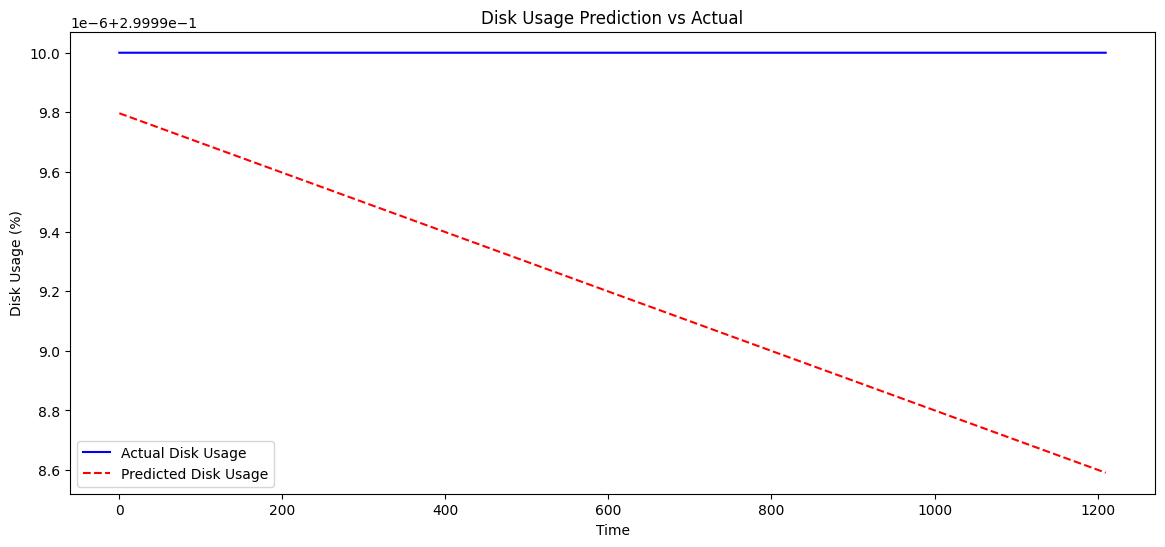

In [22]:
# Plot actual vs predicted disk usage
plt.figure(figsize=(14, 6))
plt.plot(test_rescaled, label='Actual Disk Usage', color='blue')
plt.plot(forecast_rescaled, label='Predicted Disk Usage', color='red', linestyle='--')
plt.title('Disk Usage Prediction vs Actual')
plt.xlabel('Time')
plt.ylabel('Disk Usage (%)')
plt.legend()
plt.show()
